# Facial Detection

We'll be using three datasets in this lab. In order to train our facial detection models, we'll need a dataset of positive examples (i.e., of faces) and a dataset of negative examples (i.e., of things that are not faces). We'll use these data to train our models to classify images as either faces or not faces. Finally, we'll need a test dataset of face images. Since we're concerned about the potential *bias* of our learned models against certain demographics, it's important that the test dataset we use has equal representation across the demographics or features of interest. In this lab, we'll consider skin tone and gender.

1.   **Positive training data**: [CelebA Dataset](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). A large-scale (over 200K images) of celebrity faces.
2.   **Negative training data**: [ImageNet](http://www.image-net.org/). Many images across many different categories. We'll take negative examples from a variety of non-human categories.
[Fitzpatrick Scale](https://en.wikipedia.org/wiki/Fitzpatrick_scale) skin type classification system, with each image labeled as "Lighter'' or "Darker''.

Let's begin by importing these datasets. We've written a class that does a bit of data pre-processing to import the training data in a usable format.

In [1]:
import numpy as np
import torch
import torchvision
import tqdm
from torch import nn
from torch.utils.data import DataLoader, Subset

In [2]:
data = "./"

In [3]:
# train_ds, val_ds,test_ds= torchvision.datasets.CelebA(
#     data,
#     download=True,
#     split='train',
#     target_type='attr',
#     #transform=
# ), torchvision.datasets.CelebA(
#     data,
#     download=False,
#     split='valid',
#     target_type='attr'
# ), torchvision.datasets.CelebA(
#     data,
#     download=False,
#     split='test',
#     target_type='attr'
# )

In [4]:
get_smile = lambda attr: attr[18]
train_transform = [
    torchvision.transforms.ToTensor(),
    torchvision.transforms.RandomCrop([178, 178]),
    torchvision.transforms.Resize([64, 64]),
]
transform = [
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop([178, 178]),
    torchvision.transforms.Resize([64, 64]),
]

In [5]:
def get_datasets(train_transforms=(), val_transforms=(), test_transforms=()):
    train_ds, val_ds, test_ds = (
        torchvision.datasets.CelebA(
            data,
            download=False,
            split="train",
            target_type="attr",
            transform=torchvision.transforms.Compose(train_transforms),
            target_transform=get_smile,
        ),
        torchvision.datasets.CelebA(
            data,
            download=False,
            split="valid",
            target_type="attr",
            transform=torchvision.transforms.Compose(val_transforms),
            target_transform=get_smile,
        ),
        torchvision.datasets.CelebA(
            data,
            download=False,
            split="test",
            target_type="attr",
            transform=torchvision.transforms.Compose(test_transforms),
            target_transform=get_smile,
        ),
    )

    return train_ds, val_ds, test_ds

In [6]:
train_ds, val_ds, test_ds = get_datasets(train_transform, transform, transform)

In [7]:
device = "mps"

In [8]:
# train_ds = train_ds.to(device)

In [9]:
data, label = train_ds[0]

In [10]:
label

tensor(1)

In [11]:
data.shape

torch.Size([3, 64, 64])

In [12]:
import matplotlib.pyplot as plt

In [13]:
# ax = fig.add_subplot(2, 5, 1)
# ax.set_title('Crop to a \nbounding-box', size=15)
# ax.imshow(data)

In [14]:
torch.manual_seed(42)
len(train_ds)

162770

In [15]:
batch_size = 2
epochs = 5

In [16]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

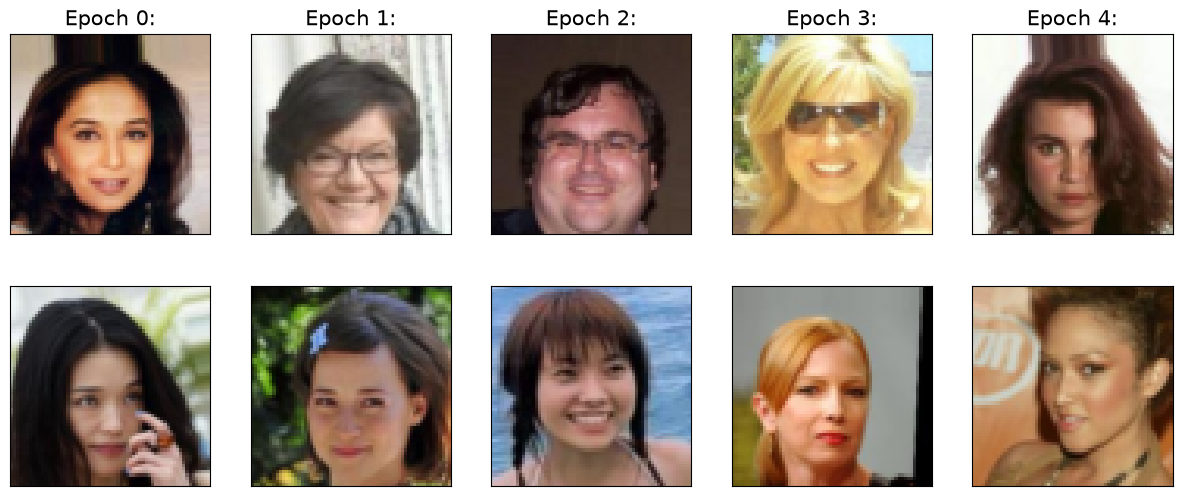

In [17]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 6))
for j in range(epochs):
    img_batch, label_batch = next(iter(train_loader))
    img = img_batch[0]
    ax = fig.add_subplot(2, 5, j + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Epoch {j}:", size=15)
    ax.imshow(img.permute(1, 2, 0))

    img = img_batch[1]
    ax = fig.add_subplot(2, 5, j + 6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img.permute(1, 2, 0))


plt.savefig("celebs.png", dpi=300)
plt.show()

In [18]:
model_sequential = nn.Sequential()

In [19]:
data, label = train_ds[0]
# data=data.to(device)
data.shape, label.shape

(torch.Size([3, 64, 64]), torch.Size([]))

In [20]:
label

tensor(1)

In [21]:
model_sequential.add_module(
    "conv1",
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=2),
)

In [22]:
x = torch.ones((4, 3, 64, 64))

In [23]:
model_sequential(x).shape

torch.Size([4, 32, 32, 32])

In [24]:
# model_sequential(data).shape

In [25]:
model_sequential

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
)

In [26]:
model_sequential.add_module("relu1", nn.ReLU())

In [27]:
model_sequential(x).shape

torch.Size([4, 32, 32, 32])

In [28]:
model_sequential.add_module("pool1", nn.MaxPool2d(kernel_size=4))  # ceils..

In [29]:
model_sequential  # 8 /kernel_size

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
)

In [30]:
model_sequential(x).shape

torch.Size([4, 32, 8, 8])

In [31]:
# model_sequential(data).shape

In [32]:
# x=model_sequential(data).shape

In [33]:
model_sequential.add_module("pool1", nn.MaxPool2d(kernel_size=8))

In [34]:
model_sequential(x).shape

torch.Size([4, 32, 4, 4])

In [35]:
model_sequential.add_module("flatten1", nn.Flatten())  # Fully connected=> x[1]*x[2]

In [36]:
model_sequential(x).shape

torch.Size([4, 512])

In [37]:
for p in model_sequential.parameters():
    print(p.shape)

torch.Size([32, 3, 3, 3])
torch.Size([32])


In [38]:
# model_sequential(data).shape==[x[0],x[1]*[x[2]]]

In [39]:
# model_sequential(data).shape

In [40]:
model_sequential

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (flatten1): Flatten(start_dim=1, end_dim=-1)
)

In [41]:
x = torch.ones(4, 3, 64, 64)
model_sequential(x).shape

torch.Size([4, 512])

In [42]:
model_sequential.add_module("logits", nn.Linear(in_features=512, out_features=1))

In [43]:
model_sequential(x).shape

torch.Size([4, 1])

In [44]:
# model_sequential.pop(key=-2)

In [45]:
model_sequential

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (flatten1): Flatten(start_dim=1, end_dim=-1)
  (logits): Linear(in_features=512, out_features=1, bias=True)
)

In [46]:
# model_sequential.insert(
#     index=-2,
# )

In [47]:
model_sequential

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (flatten1): Flatten(start_dim=1, end_dim=-1)
  (logits): Linear(in_features=512, out_features=1, bias=True)
)

In [48]:
model_sequential.add_module("sigmoid", nn.Sigmoid())

In [49]:
# data.shape

In [50]:
x = torch.ones((4, 3, 64, 64))
model_sequential(x).shape

torch.Size([4, 1])

In [51]:
model_sequential = model_sequential.to(device)
# model_sequential(data).shape

In [52]:
model_sequential.get_submodule("conv1").weight.shape, model_sequential.get_submodule(
    "conv1"
).bias.shape

(torch.Size([32, 3, 3, 3]), torch.Size([32]))

In [53]:
loss_fn = torch.nn.BCELoss()
lr = 0.001
optimizer = torch.optim.Adam(model_sequential.parameters(), lr=lr)

In [54]:
model_sequential.train()

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (flatten1): Flatten(start_dim=1, end_dim=-1)
  (logits): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [55]:
x = torch.ones((4, 3, 64, 64)).to(device)

In [56]:
model_sequential(x).shape

torch.Size([4, 1])

In [57]:
model_sequential = model_sequential.to(device)

In [58]:
image, label = next(iter(train_loader))
image.shape, label.shape

(torch.Size([2, 3, 64, 64]), torch.Size([2]))

In [59]:
image = image.to(device)

In [60]:
model_sequential(image).shape

torch.Size([2, 1])

In [61]:
image[:, 0].shape

torch.Size([2, 64, 64])

In [62]:
## Subset
torch.manual_seed(42)
train_loader = Subset(train_ds, torch.arange(16000))

In [63]:
batch_size = 32

torch.manual_seed(42)
train_dl = DataLoader(train_loader, batch_size, shuffle=True)
valid_dl = DataLoader(val_ds, batch_size, shuffle=False)
test_dl = DataLoader(test_ds, batch_size, shuffle=False)

In [64]:
len(train_dl)

500

In [65]:
len(valid_dl)

621

In [66]:
len(test_dl)

624

In [67]:
d, t = next(iter(train_dl))

In [68]:
d.shape

torch.Size([32, 3, 64, 64])

In [74]:
from tqdm.auto import tqdm


def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    best_loss = float("inf")
    i = 0
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in tqdm(train_dl, desc=f"Training at epoch {epoch}"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in tqdm(valid_dl, desc=f"validation at epoch {epoch}"):
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                pred = model(x_batch)[:, 0]
                loss = loss_fn(pred, y_batch.float())
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = ((pred >= 0.5).float() == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        if epoch > 0 and loss_hist_valid[epoch] - loss_hist_valid[-1] > 0.01:
            print(loss_hist_valid[epoch], epoch, loss_hist_valid[-1])
            # best_loss=loss_hist_valid[epoch]

            torch.save(model, "best_model_" + str(epoch + 1) + ".pt")
            # return loss_hist_train,loss_hist_valid,accuracy_hist_train,accuracy_hist_valid
        print(
            f"Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f},loss train {loss_hist_train[epoch]:.4f},val loss {loss_hist_valid[epoch]:.4f}"
        )
    # i+=1
    # if best_loss>=loss_hist_valid[-1] and i!=1:
    #     best_loss=loss_hist_valid[-1]
    #     torch.save(model.state_dict(),"best_model_"+str(i)+".pt")
    #     return loss_hist_train,loss_hist_valid,accuracy_hist_train,accuracy_hist_valid
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [ ]:
loss_train, loss_valid, accuracy_train, accuracy_valid = train(
    model_sequential, 30, train_dl, valid_dl
)

Training at epoch 0:   0%|          | 0/500 [00:00<?, ?it/s]

validation at epoch 0:   0%|          | 0/621 [00:00<?, ?it/s]

Epoch 1 accuracy: 0.8246 val_accuracy: 0.8424,loss train 0.3857,val loss 0.3621


Training at epoch 1:   0%|          | 0/500 [00:00<?, ?it/s]

validation at epoch 1:   0%|          | 0/621 [00:00<?, ?it/s]

...

Training at epoch 24:   0%|          | 0/500 [00:00<?, ?it/s]

validation at epoch 24:   0%|          | 0/621 [00:00<?, ?it/s]

0.335030110410117 24 0
Epoch 25 accuracy: 0.8421 val_accuracy: 0.8542,loss train 0.3508,val loss 0.3350


Training at epoch 25:   0%|          | 0/500 [00:00<?, ?it/s]

validation at epoch 25:   0%|          | 0/621 [00:00<?, ?it/s]

In [475]:
import pandas as pd

df = pd.DataFrame.from_dict(
    {
        "accuracy_train": accuracy_train,
        "accuracy_valid": accuracy_valid,
        "loss_train": loss_train,
        "loss_valid": loss_valid,
    }
)

In [502]:
df["accuracy_train"] = df["accuracy_train"].apply(lambda x: x.numpy())
df["accuracy_valid"] = df["accuracy_valid"].apply(lambda x: x.numpy())

In [503]:
df

,accuracy_train,accuracy_valid,loss_train,loss_valid
0,0.607875,0.607389,0.683081,0.683
1,0.609500,0.607389,0.683080,0.683
2,0.609187,0.607389,0.683069,0.683
3,0.608688,0.607389,0.683057,0.683
4,0.609062,0.607389,0.683103,0.683
5,0.609625,0.607389,0.683043,0.683
6,0.608437,0.607389,0.683251,0.683
7,0.608500,0.607389,0.683164,0.683
8,0.608063,0.607389,0.683213,0.683
9,0.608688,0.607389,0.683069,0.683


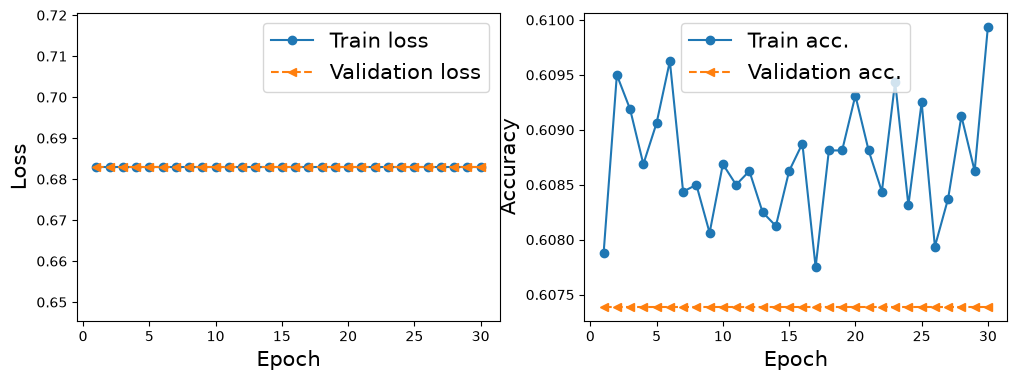

In [507]:
x_arr = np.arange(len(accuracy_train)) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, loss_valid, "-o", label="Train loss")
ax.plot(x_arr, loss_valid, "--<", label="Validation loss")
ax.legend(fontsize=15)
ax.set_xlabel("Epoch", size=15)
ax.set_ylabel("Loss", size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, accuracy_train, "-o", label="Train acc.")
ax.plot(x_arr, accuracy_valid, "--<", label="Validation acc.")
ax.legend(fontsize=15)
ax.set_xlabel("Epoch", size=15)
ax.set_ylabel("Accuracy", size=15)

# plt.savefig('figures/14_17.png', dpi=300)
plt.show()

## Residual Blocks

In [5]:
model = torch.load("best_model_15.pt")

In [7]:
model.items()

odict_items([('conv1.weight', tensor([[[[-0.0979,  0.1069, -0.1516],
          [-0.0544,  0.1381,  0.0591],
          [-0.0515,  0.0770, -0.0900]],

         [[-0.0975,  0.0577, -0.0929],
          [ 0.1339,  0.0858,  0.1169],
          [ 0.1382,  0.0243, -0.0711]],

         [[-0.1617, -0.0557, -0.1619],
          [ 0.1170,  0.0150, -0.0817],
          [-0.0060,  0.1389, -0.0843]]],


        [[[ 0.0371,  0.0231, -0.0261],
          [-0.0447,  0.0721, -0.0621],
          [-0.1580,  0.0434, -0.1119]],

         [[-0.0986,  0.0054,  0.0926],
          [-0.0558, -0.1156,  0.0889],
          [-0.1189,  0.0415,  0.0548]],

         [[-0.0046, -0.0495, -0.0259],
          [-0.1089,  0.1266, -0.0172],
          [-0.0805, -0.1054,  0.0850]]],


        [[[-0.1188,  0.0795,  0.0006],
          [-0.1777,  0.1230,  0.0758],
          [ 0.0813, -0.0863, -0.1674]],

         [[ 0.0907, -0.1500,  0.0913],
          [ 0.1667, -0.0239, -0.1560],
          [ 0.1444, -0.1844, -0.0637]],

         [[-0.

In [ ]:
class CNN